In [52]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm
import pickle 
import importlib
import run_omni_wql
importlib.reload(run_omni_wql)
from metrics import pinball_loss
from run_omni_wql import omniprediction_multiq_wql_multiH, ql_error_from_pb_loss_multiH

d = pickle.load(open('../data/hospitalizations/preprocess_data_medianinterp.pkl', 'rb'))
forecasts_dict = d['forecasts_dict']
f_list = d['forecaster_list']
alpha_list = d['alpha_list']
d['dates_list'] = d['dates_list'][:(d['dates_list'].shape[0]//7 *7)]
dates_list = pd.to_datetime(d['dates_list'])
dates_list_T = pd.to_datetime(dates_list)[::7]
Y = d['Y']
T = len(dates_list)
T_week = len(dates_list_T)
print(f_list)
print(alpha_list)
print(dates_list)
print(Y)

['CU-select', 'GT-DeepCOVID', 'COVIDhub-4_week_ensemble', 'COVIDhub-baseline', 'Karlen-pypm', 'JHU_IDD-CovidSP', 'MOBS-GLEAM_COVID', 'USC-SI_kJalpha', 'JHUAPL-Bucky', 'JHUAPL-SLPHospEns', 'JHUAPL-Gecko', 'COVIDhub-trained_ensemble']
[0.01, 0.025, 0.05, 0.1, 0.15, 0.2, 0.25, 0.3, 0.35, 0.4, 0.45, 0.5, 0.55, 0.6, 0.65, 0.7, 0.75, 0.8, 0.85, 0.9, 0.95, 0.975, 0.99]
DatetimeIndex(['2021-02-23', '2021-02-24', '2021-02-25', '2021-02-26',
               '2021-02-27', '2021-02-28', '2021-03-01', '2021-03-02',
               '2021-03-03', '2021-03-04',
               ...
               '2023-05-27', '2023-05-28', '2023-05-29', '2023-05-30',
               '2023-05-31', '2023-06-01', '2023-06-02', '2023-06-03',
               '2023-06-04', '2023-06-05'],
              dtype='datetime64[us]', length=833, freq=None)
target_end_date
2020-07-27    6100.0
2020-07-28    5257.0
2020-07-29    5387.0
2020-07-30    6288.0
2020-07-31    6034.0
               ...  
2023-06-06    1039.0
2023-06-07    1124.0


In [37]:
def decimal_to_str(eta):
    return str(np.round(eta, 4)).replace('.', ',')
    
def exp_name_string_wql_multiH(w, eta, suffix=''):
    return f"wk{w}_eta{decimal_to_str(eta)}_multiH{suffix}"

save_folder = 'hosp0315_weekly_wql_multiH'
SAVE_DIR = f'../results/{save_folder}'

eta_list = np.round(np.power(10, np.arange(-4, 2.6, 0.5)), 4)
eta_list = np.power(10, [-3.0, -2.0, -1.0, 0.0, 1.0, 2.0])
n_seed = 10
for w in range(1, 5):
    print(f"Running wk{w}...")
    for eta_mult in tqdm(eta_list, desc=f'eta_mults'):
        exp_name = exp_name_string_wql_multiH(w, eta_mult)
        results = omniprediction_multiq_wql_multiH(Y = d['Y'][d['dates_list']], 
                            H=7,
                            forecasts_dict=forecasts_dict[w], 
                            unit=100, 
                            alpha_list=d['alpha_list'], 
                            eta_multiplier=eta_mult, 
        )
        pickle.dump(results, open(f"{SAVE_DIR}/results_{exp_name}.pkl", 'wb'))

Running wk1...


eta_mults: 100%|██████████| 6/6 [00:04<00:00,  1.49it/s]


Running wk2...


eta_mults: 100%|██████████| 6/6 [00:04<00:00,  1.49it/s]


Running wk3...


eta_mults: 100%|██████████| 6/6 [00:03<00:00,  1.54it/s]


Running wk4...


eta_mults: 100%|██████████| 6/6 [00:03<00:00,  1.56it/s]


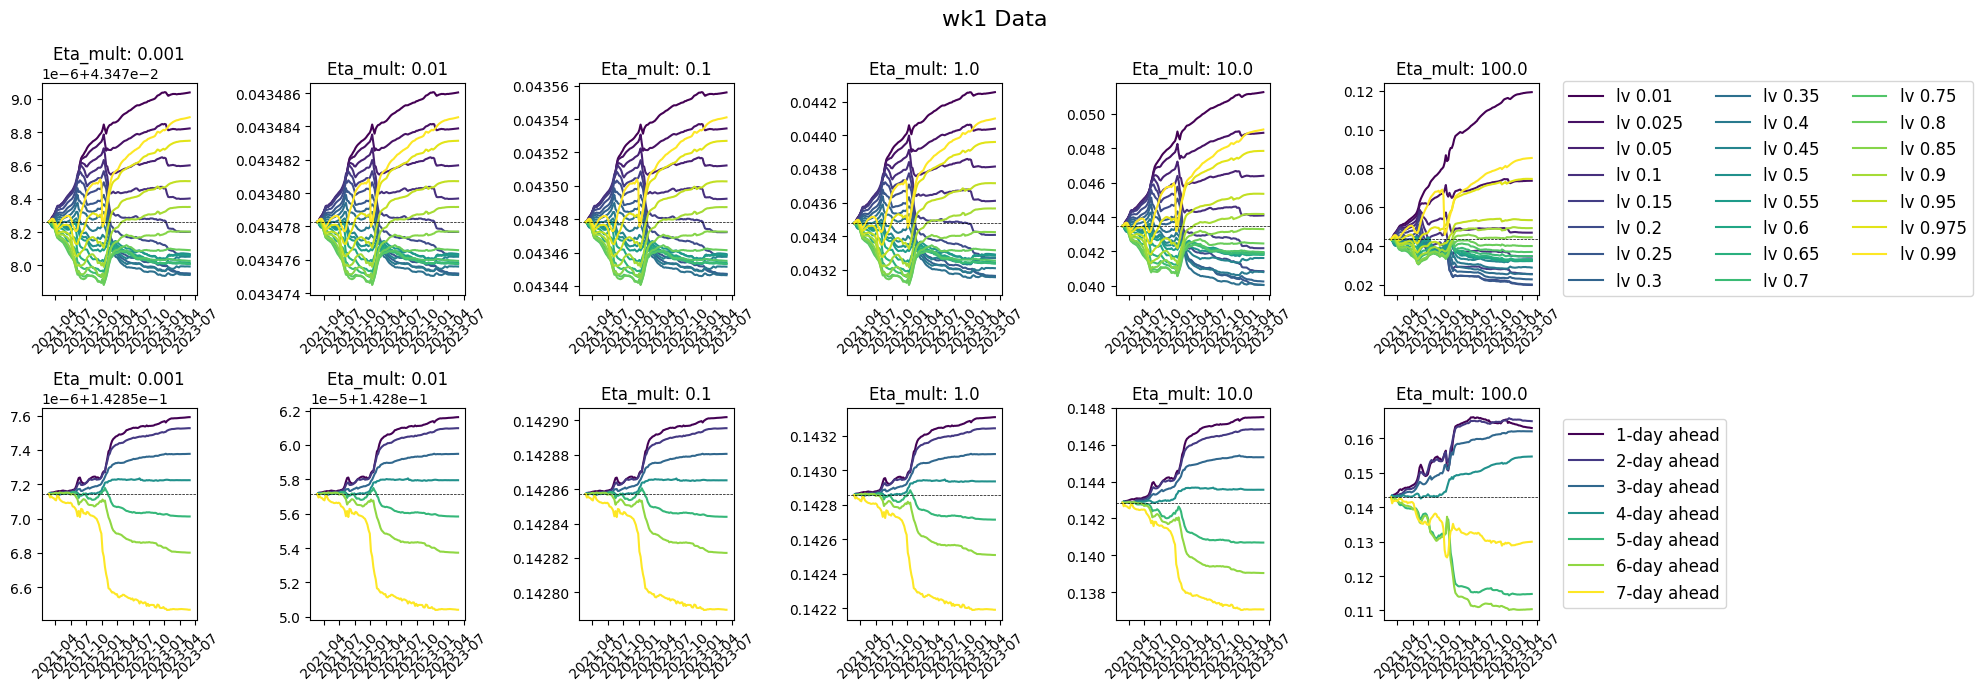

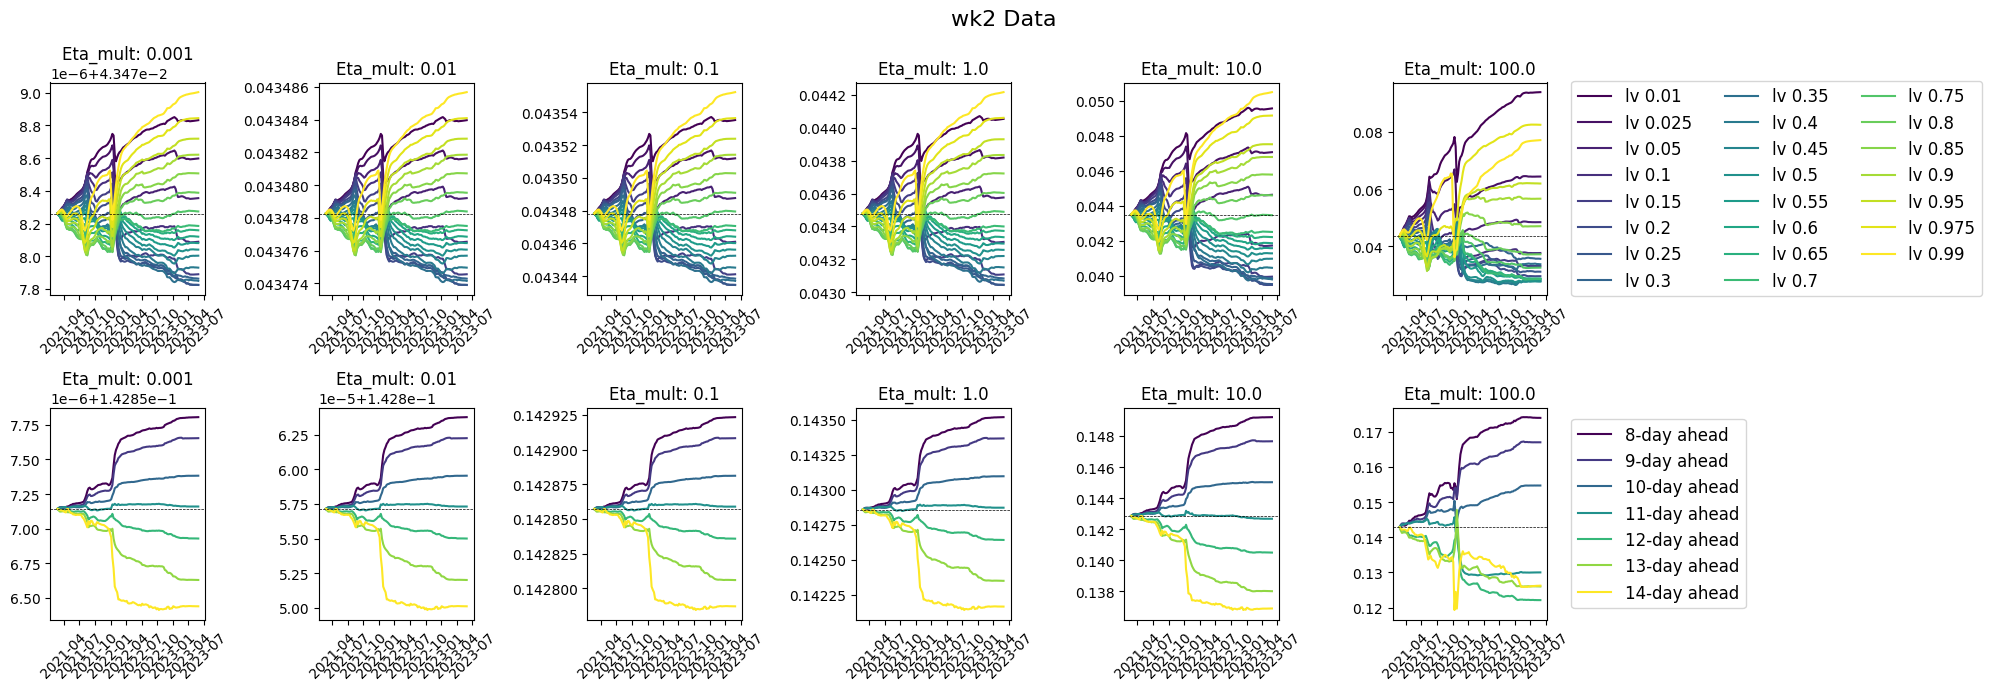

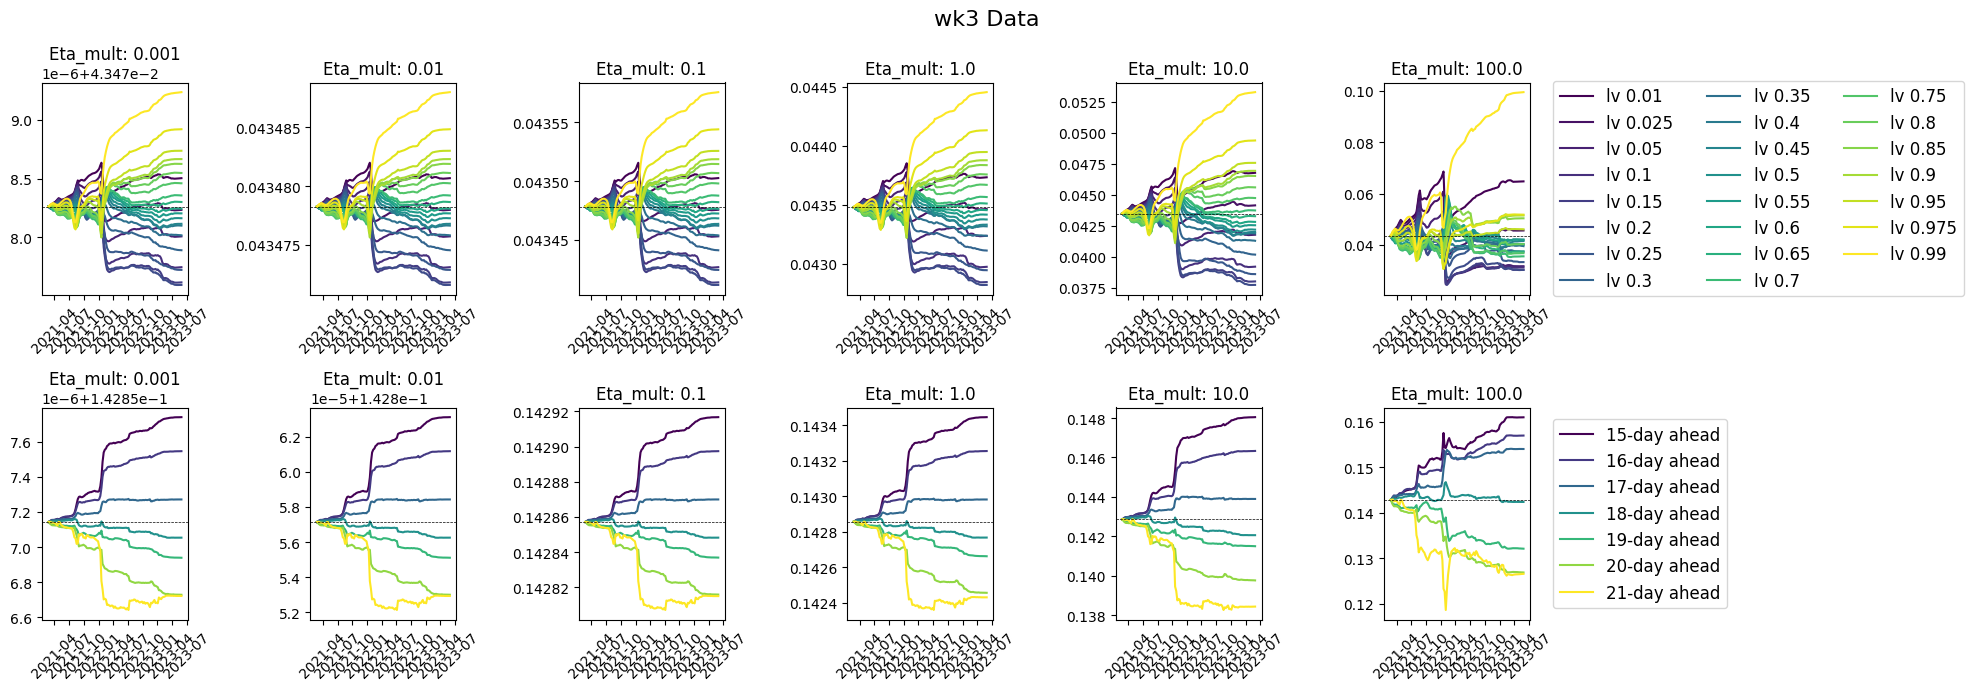

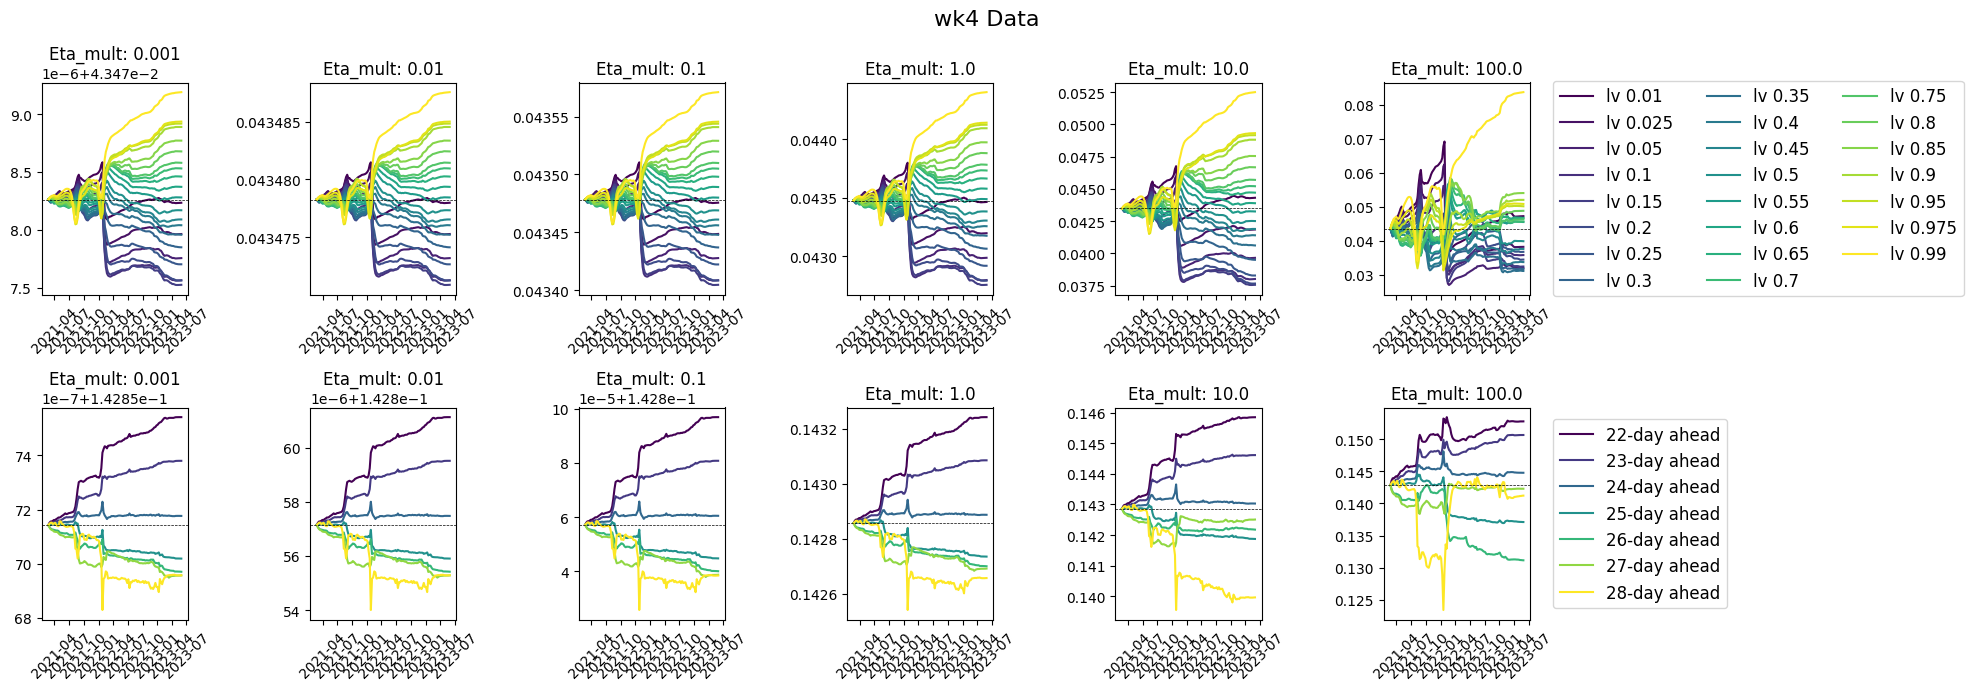

In [38]:
import matplotlib.pyplot as plt

eta_list_here = eta_list
E = len(eta_list_here)
H = 7
for w in range(1, 5):
    fig, ax = plt.subplots(2, E, figsize=(20, 7), sharey=False)
    ax = ax.flatten()
    cmap = plt.get_cmap('viridis')
    colors_N = [cmap(i / (len(alpha_list)-1)) for i in range(len(alpha_list))]
    colors_H = [cmap(i / (H-1)) for i in range(H)]

    for ix, eta_mult in enumerate(eta_list):
        results = pickle.load(open(f"{SAVE_DIR}/results_{exp_name_string_wql_multiH(w, eta_mult)}.pkl", 'rb'))

        N = results['alpha_list'].shape[0]
        w_sum_N = np.sum(results['w_history'], axis=(1,3))  # w_history: (T, H, N, F)
        for n in range(N):
            ax[ix].plot(dates_list[::7], w_sum_N[:,n], color=colors_N[n], label=f'lv {alpha_list[n]}')
        ax[ix].axhline(1/N, color='black', linewidth=0.5, linestyle='--')
        ax[ix].tick_params(axis='x', rotation=45)
        ax[ix].set_title(f'Eta_mult: {eta_mult}')

        H = results['H']
        w_sum_H = np.sum(results['w_history'], axis=(2,3))  # w_history: (T, H, N, F)
        for h in range(H):
            ax[ix+E].plot(dates_list[::7], w_sum_H[:,h], color=colors_H[h], label=f'{(w-1)*7 + h+1}-day ahead')
        ax[ix+E].axhline(1/H, color='black', linewidth=0.5, linestyle='--')
        ax[ix+E].tick_params(axis='x', rotation=45)
        ax[ix+E].set_title(f'Eta_mult: {eta_mult}')

        if ix == E-1:
            ax[ix].legend(loc='center left', bbox_to_anchor=(1.1, 0.5), fontsize=12, ncol=3)
            ax[ix+E].legend(loc='center left', bbox_to_anchor=(1.1, 0.5), fontsize=12)
    
    fig.suptitle(f'wk{w} Data', fontsize=16)
    fig.tight_layout()
    plt.show()

In [56]:
results['forecasters_pb_loss_history'][:,:,f_idx,:].shape

(119, 7, 12)

/var/folders/ph/sy2dklf10vj61gx7m16k6psr0000gn/T/ipykernel_62443/3977431267.py:25: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


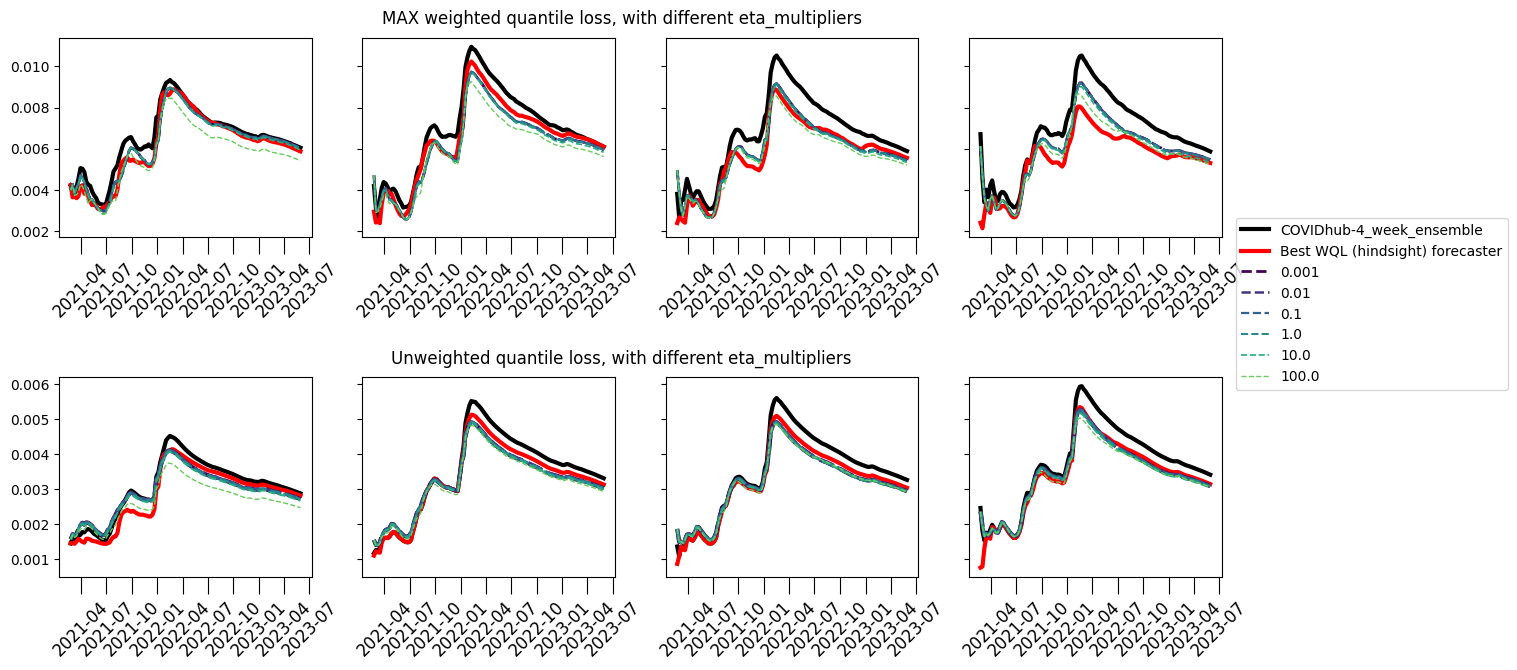

In [60]:
cmap = plt.get_cmap('viridis')
colors = [cmap(i / (len(eta_list)-1) /1.3) for i in range(len(eta_list))]

fig, axs = plt.subplots(2, 4, figsize=(15, 7), sharey='row', gridspec_kw={'hspace': 0.7})
for w in range(1,5):
    for ix, eta_mult in enumerate(eta_list):
        exp_name = exp_name_string_wql_multiH(w, eta_mult)
        results = pickle.load(open(f"{SAVE_DIR}/results_{exp_name}.pkl", 'rb'))
        if ix == 0:
            f_idx = 2
            axs[0, w-1].plot(dates_list_T, results['forecasters_score_trace'][:,f_idx], linewidth=3, color='black',label=results['forecaster_names'][f_idx])
            axs[1, w-1].plot(dates_list_T, ql_error_from_pb_loss_multiH(results['forecasters_pb_loss_history'][:,:,:,f_idx]), linewidth=3, color='black',label=results['forecaster_names'][f_idx])
            axs[0, w-1].plot(dates_list_T, results['forecasters_score_trace'].min(axis=1), linewidth=3, color='red',label='Best WQL (hindsight) forecaster')
            axs[1, w-1].plot(dates_list_T, ql_error_from_pb_loss_multiH(results['forecasters_pb_loss_history']).min(axis=1), linewidth=3, color='red',label='Best QL (hindsight) forecaster')
            axs[0, w-1].tick_params(axis='x', labelrotation=45, labelsize=12, size=12)
            axs[1, w-1].tick_params(axis='x', labelrotation=45, labelsize=12, size=12)
        axs[0, w-1].plot(dates_list_T, results['omni_score_trace'], color=colors[ix], linestyle='--', linewidth=np.linspace(2, 1, len(eta_list))[ix], label=eta_mult)
        axs[1, w-1].plot(dates_list_T, ql_error_from_pb_loss_multiH(results['omni_pb_loss_history']), color=colors[ix], linestyle='--', linewidth=np.linspace(3, 1, len(eta_list))[ix], label=eta_mult)
    
handles, labels = axs[0, w-1].get_legend_handles_labels()
fig.legend(handles, labels, loc='center', bbox_to_anchor=(1, 0.5), fontsize=10)
    
row_titles = ['MAX weighted quantile loss, with different eta_multipliers', 'Unweighted quantile loss, with different eta_multipliers']

fig.tight_layout()
for i, ax in enumerate(axs):
    # Get y-position of the subplot in figure coordinates
    bbox = ax[0].get_position()
    x_pos = 0.5  # left margin
    y_pos = bbox.y1 + 0.02
    fig.text(x_pos, y_pos, row_titles[i], ha='center', fontsize=12)

plt.show()

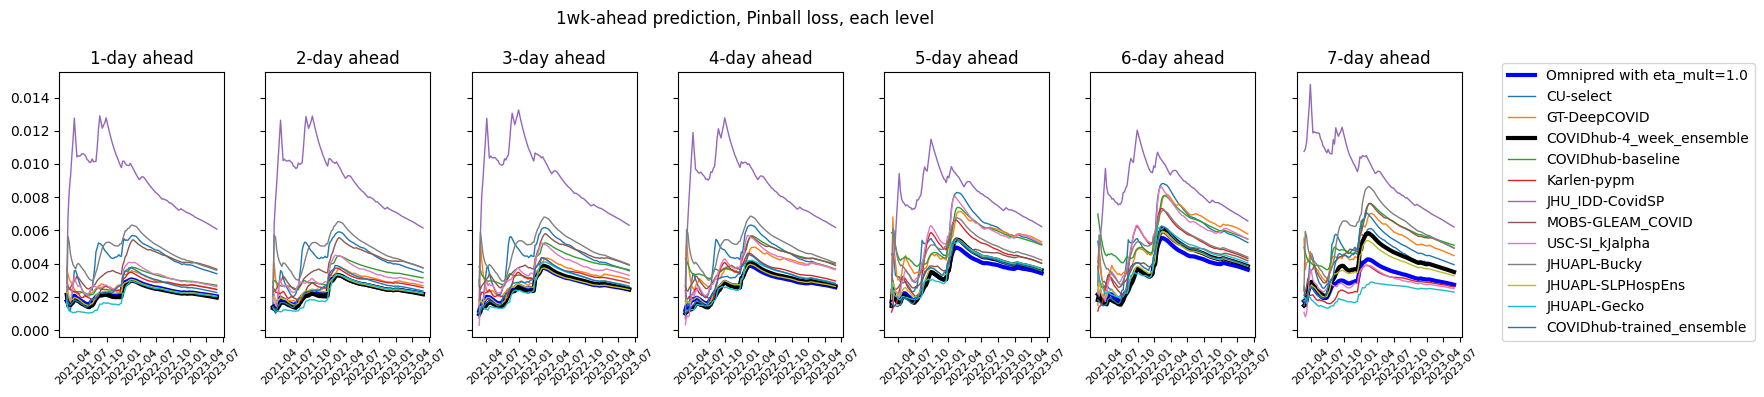

1-day ahead: ['COVIDhub-4', 'JHUAPL-Gec', 'JHUAPL-SLP', 'COVIDhub-t']
2-day ahead: ['COVIDhub-4', 'JHUAPL-SLP', 'JHUAPL-Gec', 'COVIDhub-t']
3-day ahead: ['JHUAPL-SLP', 'COVIDhub-4', 'COVIDhub-t', 'JHUAPL-Gec']
4-day ahead: ['JHUAPL-SLP', 'COVIDhub-4', 'COVIDhub-t', 'JHUAPL-Gec']
5-day ahead: ['COVIDhub-t', 'COVIDhub-4', 'JHUAPL-SLP', 'JHUAPL-Gec']
6-day ahead: ['JHUAPL-SLP', 'COVIDhub-4', 'COVIDhub-t', 'JHUAPL-Gec']
7-day ahead: ['JHUAPL-Gec', 'USC-SI_kJa', 'Karlen-pyp', 'JHUAPL-SLP']


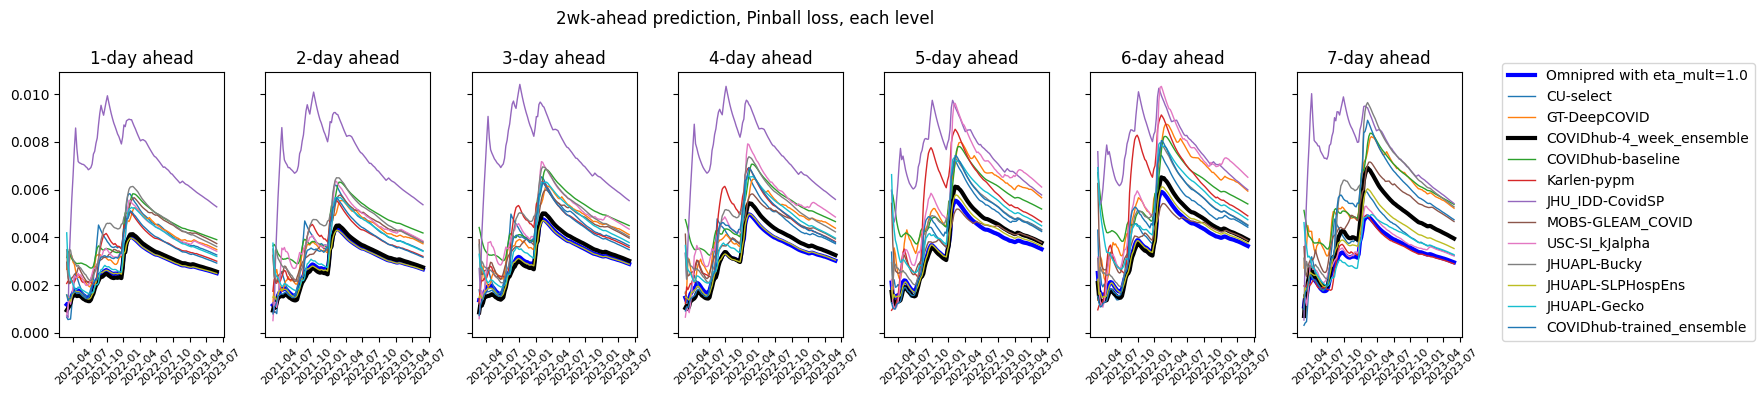

1-day ahead: ['JHUAPL-SLP', 'COVIDhub-4', 'COVIDhub-t', 'Karlen-pyp']
2-day ahead: ['JHUAPL-SLP', 'COVIDhub-4', 'COVIDhub-t', 'Karlen-pyp']
3-day ahead: ['JHUAPL-SLP', 'COVIDhub-4', 'COVIDhub-t', 'Karlen-pyp']
4-day ahead: ['JHUAPL-SLP', 'COVIDhub-4', 'CU-select', 'COVIDhub-t']
5-day ahead: ['JHUAPL-SLP', 'COVIDhub-4', 'MOBS-GLEAM', 'COVIDhub-t']
6-day ahead: ['JHUAPL-SLP', 'MOBS-GLEAM', 'COVIDhub-4', 'CU-select']
7-day ahead: ['Karlen-pyp', 'USC-SI_kJa', 'CU-select', 'JHUAPL-Gec']


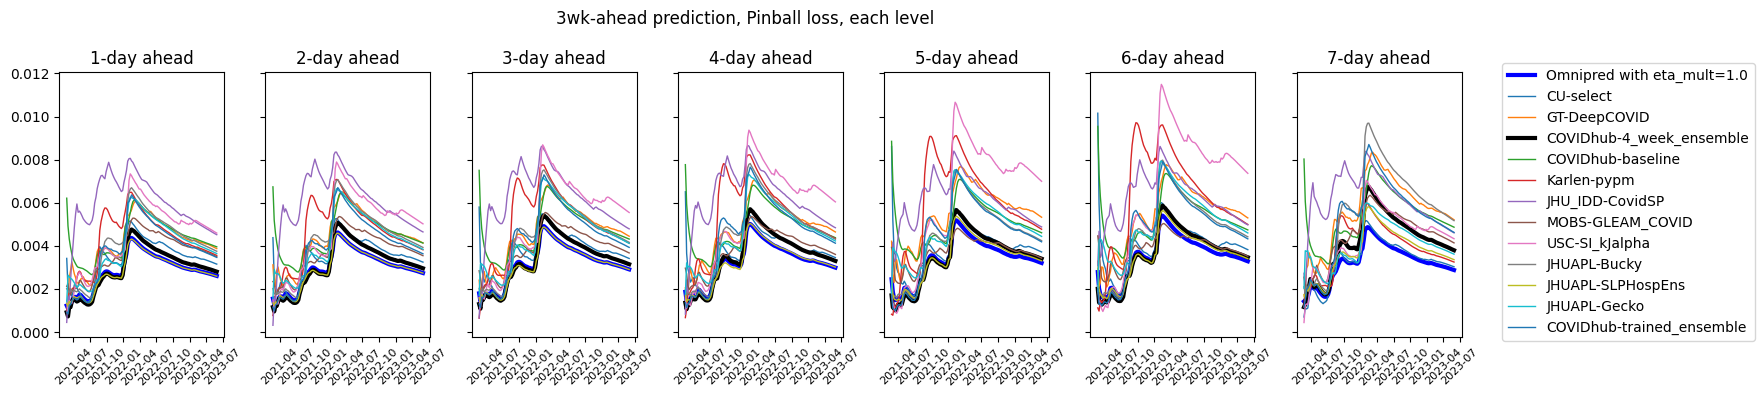

1-day ahead: ['JHUAPL-SLP', 'COVIDhub-4', 'CU-select', 'COVIDhub-t']
2-day ahead: ['JHUAPL-SLP', 'COVIDhub-4', 'CU-select', 'MOBS-GLEAM']
3-day ahead: ['JHUAPL-SLP', 'COVIDhub-4', 'CU-select', 'MOBS-GLEAM']
4-day ahead: ['JHUAPL-SLP', 'COVIDhub-4', 'CU-select', 'MOBS-GLEAM']
5-day ahead: ['JHUAPL-SLP', 'COVIDhub-4', 'MOBS-GLEAM', 'CU-select']
6-day ahead: ['JHUAPL-SLP', 'COVIDhub-4', 'MOBS-GLEAM', 'CU-select']
7-day ahead: ['CU-select', 'Karlen-pyp', 'JHUAPL-SLP', 'JHUAPL-Gec']


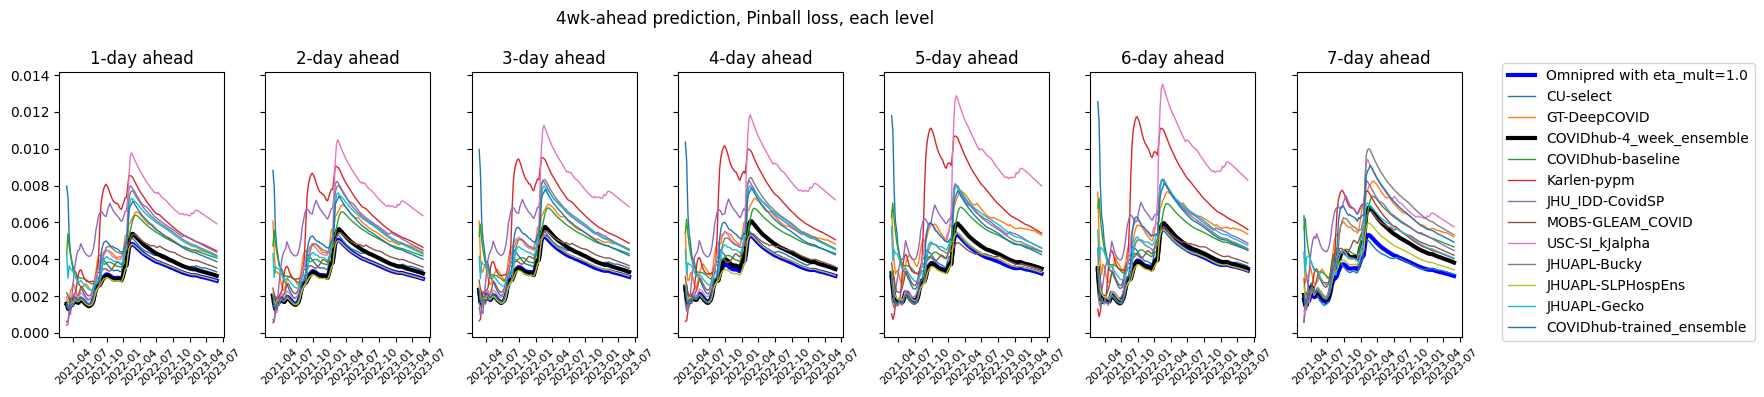

1-day ahead: ['JHUAPL-SLP', 'COVIDhub-4', 'CU-select', 'MOBS-GLEAM']
2-day ahead: ['JHUAPL-SLP', 'COVIDhub-4', 'CU-select', 'MOBS-GLEAM']
3-day ahead: ['JHUAPL-SLP', 'COVIDhub-4', 'CU-select', 'MOBS-GLEAM']
4-day ahead: ['JHUAPL-SLP', 'COVIDhub-4', 'CU-select', 'MOBS-GLEAM']
5-day ahead: ['JHUAPL-SLP', 'MOBS-GLEAM', 'COVIDhub-4', 'CU-select']
6-day ahead: ['JHUAPL-SLP', 'COVIDhub-4', 'CU-select', 'MOBS-GLEAM']
7-day ahead: ['CU-select', 'JHUAPL-SLP', 'COVIDhub-4', 'Karlen-pyp']


In [ ]:
# Each quantile level
eta_mult = 1.0
dates_list_T = pd.to_datetime(dates_list)[::7]
H = 7

for w in range(1,5):   
    fig, ax = plt.subplots(1, H, figsize=(15, 4), sharey=True)
    ax = ax.flatten()
    results = pickle.load(open(f"{SAVE_DIR}/results_{exp_name_string_wql_multiH(w, eta_mult)}.pkl", 'rb'))
    
    T_week = results['T']

    for ix, h in enumerate(range(results['H'])):
        ax[ix].plot(dates_list_T, results['omni_pb_loss_history'][:,h,:].mean(axis=1).cumsum(axis=0) / (np.arange(T_week) + 1), color='blue', linewidth=3, label=f'Omnipred with eta_mult={eta_mult}')

        for f in range(results['F']):
            single_f_pb_loss_history = results['forecasters_pb_loss_history'][:,:,:,f].mean(axis=2).cumsum(axis=0) / (np.arange(T_week) + 1)[:, None]  # forecasters_pb_loss_history: (T, H, N, F)
            if f != 2:
                ax[ix].plot(dates_list_T, single_f_pb_loss_history[:,h], linewidth=1, label=results['forecaster_names'][f])
            else:
                ax[ix].plot(dates_list_T, single_f_pb_loss_history[:,h], linewidth=3, color='black',label=results['forecaster_names'][f])

        ax[ix].tick_params(axis='x', labelrotation=45, labelsize=8)
        ax[ix].set_title(f'{ix+1}-day ahead')
        # ax[ix].set_ylim(-0.005, 0.02)
    
    handles, labels = ax[0].get_legend_handles_labels()
    fig.legend(handles, labels, loc='center left', bbox_to_anchor=(1, 0.5), fontsize=10)
    
    fig.suptitle(f'{w}wk-ahead prediction, Quantile loss')
    fig.tight_layout()
    plt.show()

    loss_each_forecaster = results['forecasters_pb_loss_history'].sum(axis=(0,2)) / T_week
    forecaster_order = np.argsort(loss_each_forecaster, axis=1)
    for h in range(H):
        print(f'{h+1}-day ahead: {[s[:10] for s in np.array(results["forecaster_names"])[forecaster_order[h,:4]]]}')

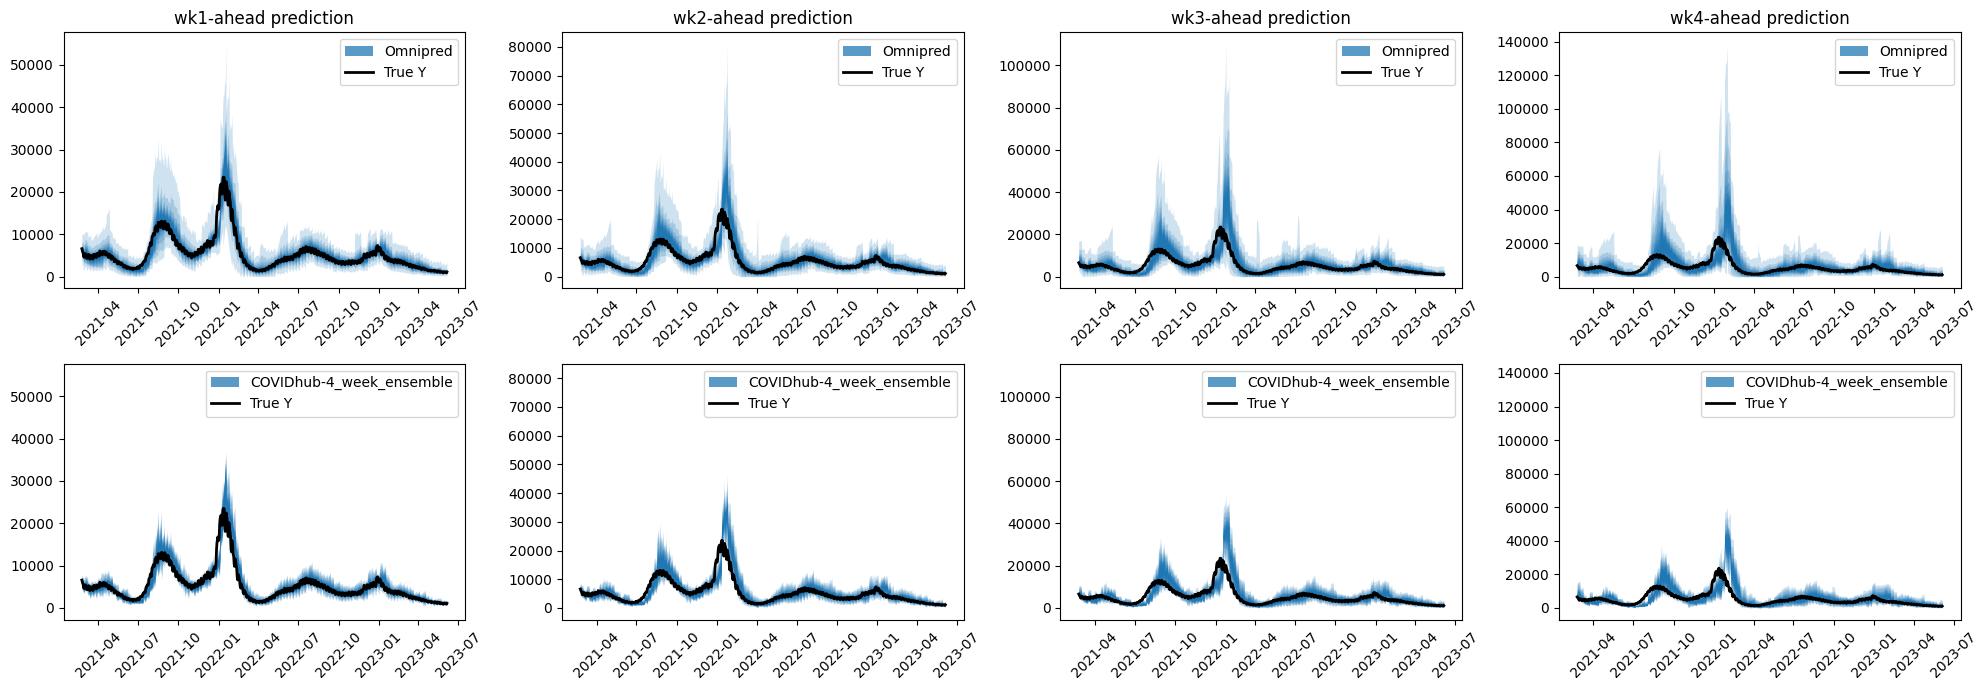

In [61]:
def quantile_plot_multiH(results, q_preds=None, color='tab:blue', alpha_list=None, ax=None, label=None):
    if ax is None:
        ax = plt.gca()
    if alpha_list is None:
        alpha_list = results['alpha_list']
    if q_preds is None:
        print("Default: using omnipred phat history")
        q_preds = results['phat_history']

    for i in range((len(alpha_list)+1) // 2):
        if alpha_list[i] + alpha_list[len(alpha_list)-1-i] != 1:
            raise ValueError("alpha_list is not symmetric")

    q_preds = q_preds.reshape(results['T']*results['H'],-1)
    
    dates_list = pd.to_datetime(results['dates_list'])
    for ia, alpha_q in enumerate(alpha_list): 
        if alpha_q > 0.5:
            break
        alpha = 0.2 + alpha_q*6/5
        ax.fill_between(dates_list, 
                        y1=q_preds[:,ia] * results['unit'], 
                        y2=q_preds[:,len(alpha_list)-1-ia] * results['unit'], 
                        color=color, alpha=alpha, linewidth=0, label=(label if ia == (len(alpha_list)//2-1) else None)
                        )
    ax.tick_params(axis='x', rotation=45)
    ax.plot(dates_list, results['Y']*results['unit'], color='black', linewidth=2, label='True Y')
    ax.legend()

    return ax

eta_mult = 1.0
fig, ax = plt.subplots(2, 4, figsize=(20, 7), sharey='col')
for w in range(1,5):   
    results = pickle.load(open(f"{SAVE_DIR}/results_{exp_name_string_wql_multiH(w, eta_mult)}.pkl", 'rb'))
    quantile_plot_multiH(results, q_preds=results['phat_history'], ax=ax[0, w-1], label='Omnipred')   # omnipred
    quantile_plot_multiH(results, q_preds=results['forecasters_preds_history'][:,:,2], ax=ax[1, w-1], label=results['forecaster_names'][2])   # pinball
    ax[0, w-1].set_title(f'wk{w}-ahead prediction')

fig.tight_layout()